In [1]:
import warnings
import logging
import transformers

warnings.filterwarnings("ignore")
transformers.logging.set_verbosity_error()

In [2]:
# loading dataset
from datasets import load_dataset

# data processing
import pandas as pd

# charts
import matplotlib.pyplot as plt
import seaborn as sns

# Pretreained HerBERT
from transformers import pipeline
from transformers import pipeline, AutoModelForCausalLM, AutoTokenizer
from langchain_huggingface import HuggingFacePipeline
from langchain_core.prompts import PromptTemplate


import torch
from sklearn.metrics import classification_report, confusion_matrix

In [3]:
dataset = load_dataset ("allegro/klej-polemo2-in", split ="test")

df = pd.DataFrame(dataset)

label_mapping = {
    '__label__meta_minus_m': 'Negative',
    '__label__meta_plus_m': 'Positive',
    '__label__meta_zero': 'Neutral',
}

df['text_length'] = df['sentence'].apply(len)

# remove ambigous target
df = df[df['target'] != '__label__meta_amb']

# map targets to more readable names
df['target'] = df['target'].map(label_mapping)

reviews_texts = df['sentence'].tolist()

In [4]:
llm_model_name = "Qwen/Qwen2.5-1.5B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(llm_model_name)

model = AutoModelForCausalLM.from_pretrained(
    llm_model_name,
    dtype=torch.float16,
    device_map="auto"
)

basic_template = """ 
Sklasyfikuj nastrój tekstu, przypisując go do jednej z trzech kategorii: Positive, Negative lub Neutral.
Odpowiedz tylko i wyłącznie jednym słowem z listy (Positive, Negative, Neutral). Nie dopisuj żadnego komentarza.

Tekst: {review}
Kategoria:"""

prompt = PromptTemplate.from_template(basic_template)


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

In [5]:
temperatures = [0.1, 0.5, 1.0, 1.5, 2.0]
predictions = []

for temp in temperatures:
    hf_pipeline = pipeline(
        "text-generation",
        model = model, 
        tokenizer = tokenizer,
        device="cuda",
        return_full_text = False,
        max_new_tokens=1,      
        temperature=temp,
        do_sample=True,
        pad_token_id=tokenizer.eos_token_id
    )   

    llm = HuggingFacePipeline(pipeline = hf_pipeline)

    llm_chain = prompt | llm
    
    preds = llm_chain.batch ([
        {"review": text} for text in reviews_texts
    ])
    
    preds = [pred.strip() for pred in preds]
    
    print(f"Predictions for temperature {temp} finished!")
    
    predictions.append(preds)

Predictions for temperature 0.1 finished!
Predictions for temperature 0.5 finished!
Predictions for temperature 1.0 finished!
Predictions for temperature 1.5 finished!
Predictions for temperature 2.0 finished!



===== TEMPERATURE 0.1 =====
              precision    recall  f1-score   support

                   0.00      0.00      0.00         0
    Negative       0.98      0.31      0.47       300
     Neutral       0.44      0.65      0.52       117
    Positive       0.79      0.87      0.83       197
          __       0.00      0.00      0.00         0
        ____       0.00      0.00      0.00         0
    ________       0.00      0.00      0.00         0

    accuracy                           0.55       614
   macro avg       0.31      0.26      0.26       614
weighted avg       0.81      0.55      0.59       614



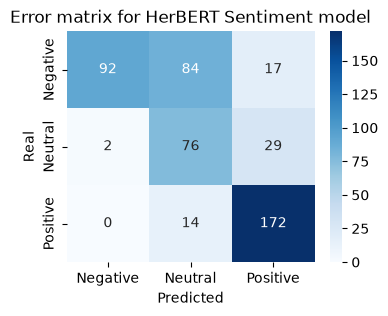



===== TEMPERATURE 0.5 =====
              precision    recall  f1-score   support

    Negative       0.97      0.25      0.40       300
     Neutral       0.45      0.62      0.52       117
    Positive       0.74      0.82      0.78       197
          __       0.00      0.00      0.00         0
        ____       0.00      0.00      0.00         0
      ______       0.00      0.00      0.00         0
    ________       0.00      0.00      0.00         0
____________       0.00      0.00      0.00         0

    accuracy                           0.50       614
   macro avg       0.27      0.21      0.21       614
weighted avg       0.80      0.50      0.55       614



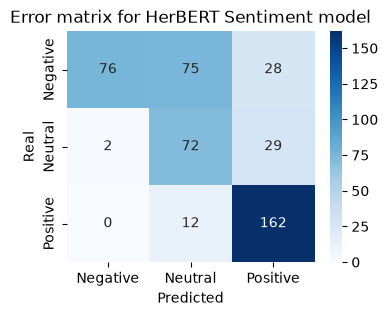



===== TEMPERATURE 1.0 =====
                  precision    recall  f1-score   support

                       0.00      0.00      0.00         0
               (       0.00      0.00      0.00         0
        Negative       0.91      0.13      0.23       300
         Neutral       0.32      0.38      0.35       117
        Positive       0.62      0.54      0.58       197
              __       0.00      0.00      0.00         0
             ___       0.00      0.00      0.00         0
            ____       0.00      0.00      0.00         0
          ______       0.00      0.00      0.00         0
        ________       0.00      0.00      0.00         0
    ____________       0.00      0.00      0.00         0
________________       0.00      0.00      0.00         0

        accuracy                           0.31       614
       macro avg       0.15      0.09      0.10       614
    weighted avg       0.70      0.31      0.37       614



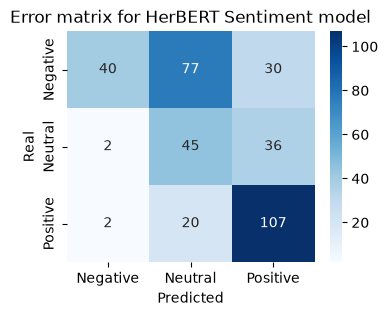



===== TEMPERATURE 1.5 =====
                  precision    recall  f1-score   support

                       0.00      0.00      0.00         0
               (       0.00      0.00      0.00         0
               -       0.00      0.00      0.00         0
              Ne       0.00      0.00      0.00         0
        Negative       0.96      0.15      0.26       300
         Neutral       0.30      0.37      0.33       117
        Positive       0.59      0.39      0.47       197
               _       0.00      0.00      0.00         0
              __       0.00      0.00      0.00         0
             ___       0.00      0.00      0.00         0
            ____       0.00      0.00      0.00         0
          ______       0.00      0.00      0.00         0
        ________       0.00      0.00      0.00         0
    ____________       0.00      0.00      0.00         0
________________       0.00      0.00      0.00         0

        accuracy                        

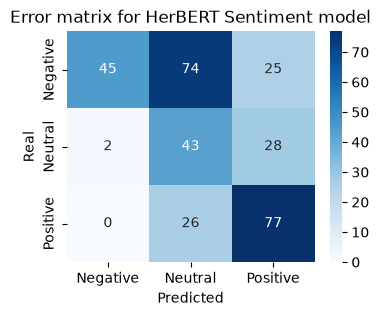



===== TEMPERATURE 2.0 =====
                  precision    recall  f1-score   support

                       0.00      0.00      0.00         0
               (       0.00      0.00      0.00         0
              ()       0.00      0.00      0.00         0
               -       0.00      0.00      0.00         0
              Ne       0.00      0.00      0.00         0
        Negative       0.82      0.11      0.19       300
         Neutral       0.26      0.27      0.27       117
             Pos       0.00      0.00      0.00         0
        Positive       0.51      0.31      0.39       197
              __       0.00      0.00      0.00         0
             ___       0.00      0.00      0.00         0
            ____       0.00      0.00      0.00         0
          ______       0.00      0.00      0.00         0
        ________       0.00      0.00      0.00         0
    ____________       0.00      0.00      0.00         0
________________       0.00      0.00    

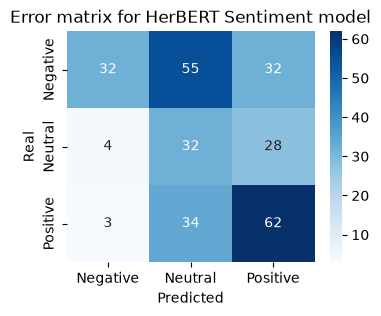

In [10]:
from sklearn.metrics import f1_score, accuracy_score

accuracy_scores = []
f1_scores = []

for temp, preds in zip(temperatures, predictions):
    print(f"\n===== TEMPERATURE {temp} =====")

    print(classification_report(df['target'], preds))

    plt.figure(figsize=(4, 3))
    cm = confusion_matrix(df['target'], preds, labels=['Negative', 'Neutral', 'Positive'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Neutral', 'Positive'], yticklabels=['Negative', 'Neutral', 'Positive'])
    plt.ylabel('Real')
    plt.xlabel('Predicted')
    plt.title('Error matrix for HerBERT Sentiment model')
    plt.show()

    print()

    accuracy_scores.append(accuracy_score(df['target'], preds))
    f1_scores.append(f1_score(df['target'], preds, average='weighted'))

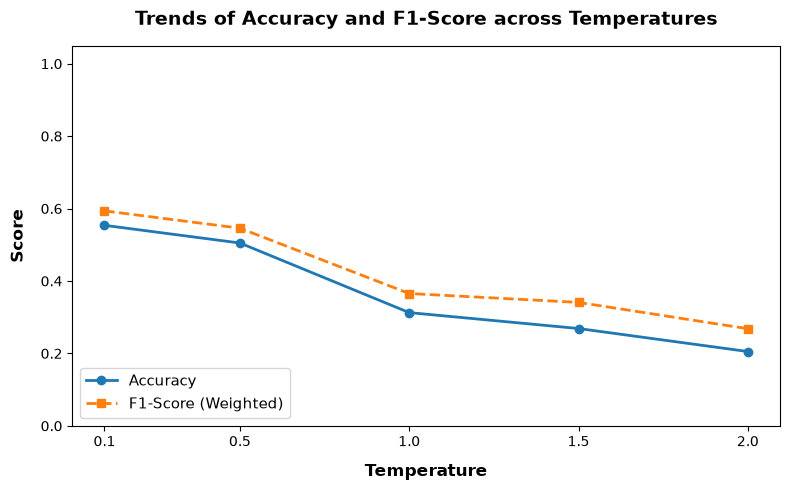

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(temperatures, accuracy_scores, marker='o', linewidth=2, label='Accuracy', color='#1f77b4')
ax.plot(temperatures, f1_scores, marker='s', linewidth=2, linestyle='--', label='F1-Score (Weighted)', color='#ff7f0e')

ax.set_xlabel('Temperature', fontsize=12, fontweight='bold', labelpad=10)
ax.set_ylabel('Score', fontsize=12, fontweight='bold', labelpad=10)
ax.set_title('Trends of Accuracy and F1-Score across Temperatures', fontsize=14, fontweight='bold', pad=15)
ax.set_xticks(temperatures)
ax.set_ylim(0.0, 1.05)
ax.legend(fontsize=11, loc='lower left', frameon=True)

plt.tight_layout()
plt.show()